# Práctica 01: serie mensual del sector eléctrico con Yahoo Finance

Aplicación de Box–Jenkins al precio mensual de cierre de NextEra Energy (`NEE`), empresa del sector eléctrico. Flujo: datos, gráfico, ADF, diferenciación, FAC/FACP, AR/MA/ARMA/ARIMA, pronóstico y diagnóstico.

## 1. Librerías

Si se utiliza otro entorno, instalar primero: `%pip install yfinance pandas numpy matplotlib statsmodels`.

In [1]:
import warnings

import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.sm_exceptions import InterpolationWarning

plt.rcParams['figure.figsize'] = (10, 4)
alpha = 0.05

## 2. Llamado al dataset con Yahoo Finance

Yahoo Finance no ofrece la producción física de electricidad. Se usa `NEE` (NextEra Energy) como empresa generadora eléctrica y se analiza su precio de cierre mensual. Para otra empresa del sector, cambia `simbolo` por `DUK`, `SO`, `XEL` o `VST`.

In [2]:
simbolo = 'NEE'
inicio, fin = '2000-01-01', '2026-01-01'
data = yf.Ticker(simbolo).history(start=inicio, end=fin, interval='1mo', auto_adjust=False, actions=False)
if data.empty: raise ValueError('Yahoo no devolvió datos. Revisa ticker o conexión.')
data.index = pd.to_datetime(data.index, utc=True).tz_convert(None)
data = data.sort_index()
data.index = data.index.to_period('M').to_timestamp()
data = data[~data.index.duplicated(keep='first')]
serie = data['Close'].dropna().astype(float).asfreq('MS')
if len(serie) < 80: raise ValueError('Se necesitan al menos 80 observaciones.')
print(f'{simbolo}: {len(serie)} observaciones mensuales')
print(f'Desde {serie.index.min().date()} hasta {serie.index.max().date()}')

NEE: 312 observaciones mensuales
Desde 2000-01-01 hasta 2025-12-01


## 3. Dataset y preparación

`Open`, `High`, `Low` y `Close` son precios en USD; `Volume` es el volumen reportado. La variable del modelo será **Close**.

In [3]:
print('Dimensiones:', data.shape)
print('Periodo:', data.index.min().date(), 'a', data.index.max().date())
display(data.head())
display(data.tail())
data.info()

Dimensiones: (312, 6)
Periodo: 2000-01-01 a 2025-12-01


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-01,5.296875,5.648438,5.125000,5.273438,2.259975,95782400
2000-02-01,5.226563,5.398438,4.546875,4.828125,2.096833,116946400
2000-03-01,4.828125,6.031250,4.710938,5.757813,2.500593,178841600
2000-04-01,5.742188,6.007813,5.226563,5.656250,2.456485,118757600
2000-05-01,5.750000,6.250000,5.593750,6.210938,2.727993,128780000


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2025-08-01,71.430000,77.419998,70.180000,72.050003,70.037201,195668700
2025-09-01,72.269997,76.699997,69.239998,75.489998,73.381104,209275300
2025-10-01,76.330002,87.529999,76.220001,81.400002,79.126007,238979700
2025-11-01,81.300003,86.690002,80.599998,86.290001,84.447388,179492400
2025-12-01,85.589996,85.970001,78.720001,80.279999,78.565720,210525800


<class 'pandas.DataFrame'>
DatetimeIndex: 312 entries, 2000-01-01 to 2025-12-01
Freq: MS
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       312 non-null    float64
 1   High       312 non-null    float64
 2   Low        312 non-null    float64
 3   Close      312 non-null    float64
 4   Adj Close  312 non-null    float64
 5   Volume     312 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 17.1 KB


In [4]:
display(data.describe().T)
display(data.isna().sum().rename('Nulos').to_frame())
print('Fechas duplicadas:', data.index.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
Open,312.0,3.123631e+01,2.582786e+01,4.828125e+00,1.079875e+01,1.774875e+01,5.007250e+01,9.342000e+01
High,312.0,3.290163e+01,2.743871e+01,5.398438e+00,1.138750e+01,1.829625e+01,5.245188e+01,9.373000e+01
Low,312.0,2.969442e+01,2.433449e+01,4.546875e+00,1.041312e+01,1.734000e+01,4.693062e+01,8.602000e+01
Close,312.0,3.145341e+01,2.589252e+01,4.828125e+00,1.103063e+01,1.784625e+01,5.135938e+01,9.336000e+01
Adj Close,312.0,2.550165e+01,2.485548e+01,2.096833e+00,6.114746e+00,1.221968e+01,4.286514e+01,8.444739e+01
Volume,312.0,1.808447e+08,5.444769e+07,9.199120e+07,1.437181e+08,1.696412e+08,2.077265e+08,5.031760e+08


,Nulos
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Fechas duplicadas: 0


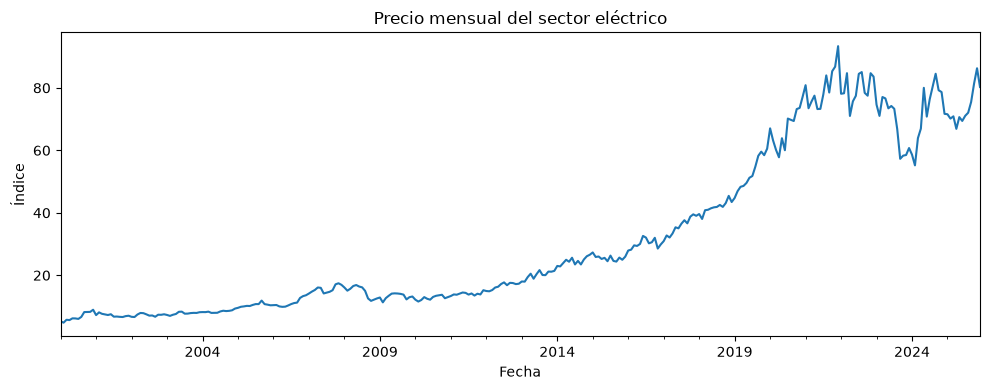

In [5]:
data = data.loc[~data.index.duplicated(keep='first')].copy()
serie = data['Close'].astype(float).dropna()
serie.index = serie.index.to_period('M').to_timestamp()
serie = serie.asfreq('MS')
if (serie <= 0).any(): raise ValueError('Hay valores no positivos.')
serie.plot(title='Precio mensual del sector eléctrico', ylabel='Índice', xlabel='Fecha')
plt.tight_layout(); plt.show()

## 4. Fase 1: identificación y estacionariedad

### 4.1. División temporal

El primer 80 % se utiliza para identificar y ajustar el modelo. El último 20 % se reserva para evaluar el pronóstico. Las pruebas y la elección de parámetros usan solamente `train`.

,Datos,Desde,Hasta
Entrenamiento,249,2000-01-01,2020-09-01
Prueba,63,2020-10-01,2025-12-01


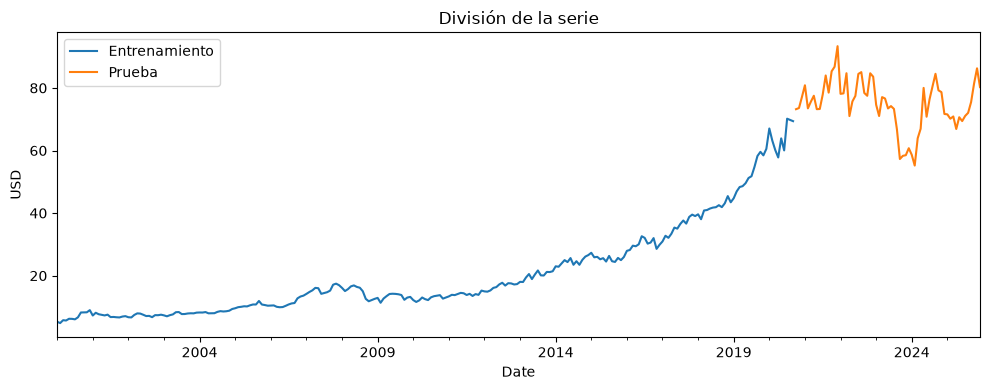

In [6]:
corte = int(len(serie) * 0.8)
train = serie.iloc[:corte]
test = serie.iloc[corte:]

display(pd.DataFrame({
    'Datos': [len(train), len(test)],
    'Desde': [train.index.min().date(), test.index.min().date()],
    'Hasta': [train.index.max().date(), test.index.max().date()]
}, index=['Entrenamiento', 'Prueba']))

train.plot(label='Entrenamiento')
test.plot(label='Prueba')
plt.title('División de la serie')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Estacionariedad

ADF: H₀ = la serie no es estacionaria; Hₐ = la serie es estacionaria. Si p-valor < 0,05 se rechaza H₀.

In [7]:
def prueba_adf(x, nombre):
    r = adfuller(x.dropna(), autolag='AIC', result_object=False)
    print(f'{nombre}: ADF={r[0]:.4f}; p-valor={r[1]:.4f};', 'estacionaria' if r[1] < alpha else 'no estacionaria')
    return r[1]
corte = int(len(serie) * 0.8)
train, test = serie.iloc[:corte], serie.iloc[corte:]
p0 = prueba_adf(train, 'Original')

Original: ADF=5.0536; p-valor=1.0000; no estacionaria


### Diferenciación

Se revisan d=0, d=1 y d=2. Se usa el menor orden que pase ADF.

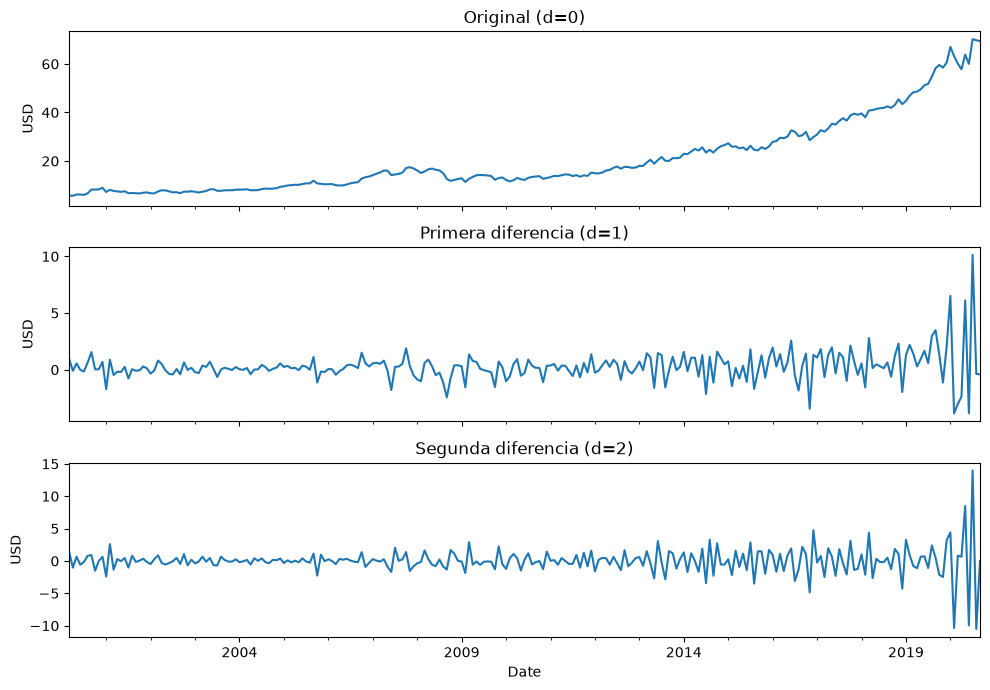

In [8]:
train_diff = train.diff().dropna()
train_diff2 = train_diff.diff().dropna()
series = [train, train_diff, train_diff2]
nombres = ['Original (d=0)', 'Primera diferencia (d=1)', 'Segunda diferencia (d=2)']

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for x, nombre, ax in zip(series, nombres, axes):
    x.plot(ax=ax, title=nombre)
    ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

In [9]:
p1 = prueba_adf(train_diff, 'Primera diferencia')
p2 = prueba_adf(train_diff2, 'Segunda diferencia')
if p0 < alpha: d = 0
elif p1 < alpha: d = 1
elif p2 < alpha: d = 2
else: raise ValueError('No se logró estacionariedad con d=0, 1 o 2.')
serie_estacionaria = [train, train_diff, train_diff2][d]
print(f'Orden elegido: d={d}')
serie_estacionaria = [train, train_diff, train_diff2][d]


Primera diferencia: ADF=-4.2681; p-valor=0.0005; estacionaria
Segunda diferencia: ADF=-7.2448; p-valor=0.0000; estacionaria
Orden elegido: d=1


### 4.6. FAC y FACP para identificar p y q

| Modelo sobre la serie estacionaria | FAC | FACP |
|---|---|---|
| AR(p) | Decae gradualmente | Corte después de p |
| MA(q) | Corte después de q | Decae gradualmente |
| ARMA(p,q) | Decae gradualmente | Decae gradualmente |

Estos patrones son orientativos. Se comparan órdenes pequeños con AIC y BIC para apoyar la elección.

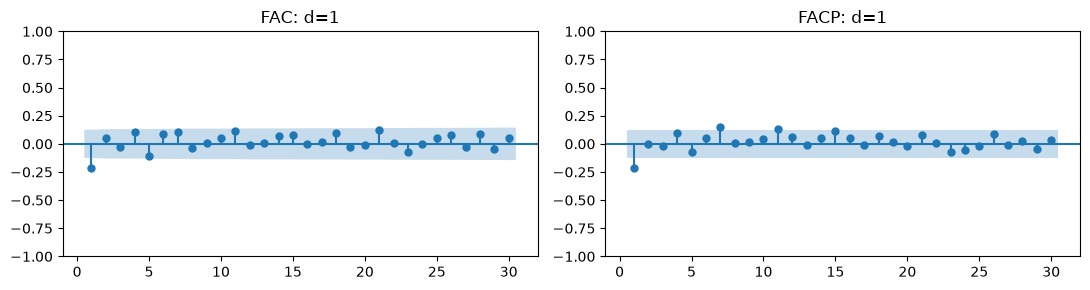

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(serie_estacionaria, lags=30, zero=False, ax=axes[0], title=f'FAC: d={d}')
plot_pacf(serie_estacionaria, lags=30, zero=False, method='ywm', ax=axes[1],
          title=f'FACP: d={d}')
plt.tight_layout()
plt.show()

## 5. Fase 2: estimación y comparación de modelos

Con `d=0`, ARIMA(p,0,0) es AR, ARIMA(0,0,q) es MA y ARIMA(p,0,q) es ARMA. Con `d>0`, el modelo de la serie original es **ARIMA(p,d,q)**, aunque las diferencias se modelen con AR, MA o ARMA.

Se prueban `p` y `q` entre 0 y 3. Se incluye ARIMA(0,1,0), un paseo aleatorio sin deriva, cuando `d=1`. Se ajusta **train original**: ARIMA realiza las diferencias internamente y devuelve pronósticos en USD. Se usa constante si `d=0` y sin tendencia determinista si `d>0`.

In [11]:
modelos, resultados = {}, []
trend = 'c' if d == 0 else 'n'
for p in range(3):
    for q in range(3):
        orden = (p, d, q)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                ajuste = ARIMA(train, order=orden, trend=trend, freq='MS').fit()
            if np.isfinite(ajuste.aic):
                modelos[orden] = ajuste
                resultados.append({'Orden': orden, 'AIC': ajuste.aic, 'BIC': ajuste.bic})
        except (ValueError, np.linalg.LinAlgError): pass
if not resultados: raise ValueError('No se pudo ajustar ningún modelo.')
comparacion = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
display(comparacion)
orden_elegido = tuple(comparacion.loc[0, 'Orden'])
modelo = modelos[orden_elegido]
print('Modelo elegido por AIC: ARIMA', orden_elegido)
nombre = f'ARIMA{orden_elegido}'


,Orden,AIC,BIC
0,"(2, 1, 1)",831.877029,845.930744
1,"(1, 1, 0)",847.985733,855.012591
2,"(1, 1, 1)",848.621346,859.161632
3,"(0, 1, 2)",848.906484,859.446770
4,"(0, 1, 1)",848.996825,856.023683
5,"(2, 1, 0)",849.173239,859.713525
6,"(1, 1, 2)",850.116304,864.170019
7,"(2, 1, 2)",852.115734,869.682878
8,"(0, 1, 0)",853.531320,857.044749


Modelo elegido por AIC: ARIMA (2, 1, 1)


## 6. Fase 3: diagnóstico de residuos

### 6.1. Selección con AIC y Ljung–Box

Un AIC menor indica un mejor equilibrio entre ajuste y complejidad dentro de esta comparación. Siguiendo Box–Jenkins, se revisan los modelos en ese orden y se elige el primero sin autocorrelación residual detectada a 10 y 20 rezagos.

Ljung–Box: H₀ = no hay autocorrelación hasta el rezago evaluado. Se descartan los residuos iniciales de inicialización y se descuentan `p+q` grados de libertad. Pasar esta prueba no garantiza independencia ni varianza constante.

In [12]:
residuales = modelo.resid.dropna()
print('Residuos disponibles:', len(residuales))

Residuos disponibles: 249


### 6.2. Gráficos de los residuos

### 6.3. Ljung–Box, ARCH y Jarque–Bera

ARCH contrasta ausencia de heterocedasticidad condicional; Jarque–Bera contrasta normalidad. Si p < 0,05 se rechaza su hipótesis nula. Una media próxima a cero se revisa descriptivamente.

In [13]:
lb = acorr_ljungbox(residuales, lags=[10], return_df=True)
arch = het_arch(residuales, nlags=10, result_object=False)
jb = jarque_bera(residuales)
pruebas = pd.DataFrame({'Prueba':['Ljung–Box','ARCH','Jarque–Bera'], 'Estadístico':[lb['lb_stat'].iloc[0],arch[0],jb[0]], 'p-valor':[lb['lb_pvalue'].iloc[0],arch[1],jb[1]]})
display(pruebas)
print(f'Media de residuos: {residuales.mean():.4f}')

,Prueba,Estadístico,p-valor
0,Ljung–Box,9.609237,4.754184e-01
1,ARCH,152.296572,1.255333e-27
2,Jarque–Bera,1035.364455,1.490958e-225


Media de residuos: 0.1369


## 7. Fase 4: pronóstico y evaluación

### 7.1. Pronóstico del conjunto de prueba

El modelo queda fijado antes de consultar los errores de prueba. Se pronostica todo el bloque desde el último día de entrenamiento, sin actualizar con valores de `test`. Se compara con una referencia ingenua: repetir el último cierre conocido.

Los intervalos del 95 % dependen de los supuestos del modelo; su cobertura puede ser inadecuada si ARCH o Jarque–Bera rechazan sus hipótesis.

,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2020-10-01,73.209999,70.512372,69.389999,68.022813,73.001930
2020-11-01,73.589996,71.220084,69.389999,68.083807,74.356362
2020-12-01,77.150002,72.036902,69.389999,68.231862,75.841942
2021-01-01,80.870003,72.821394,69.389999,68.437361,77.205427
2021-02-01,73.480003,73.611761,69.389999,68.679168,78.544354


,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2025-08-01,72.050003,113.032696,69.389999,81.651571,144.413821
2025-09-01,75.489998,113.707134,69.389999,81.788188,145.626081
2025-10-01,81.400002,114.379657,69.389999,81.920962,146.838353
2025-11-01,86.290001,115.050270,69.389999,82.049913,148.050628
2025-12-01,80.279999,115.718979,69.389999,82.175064,149.262893


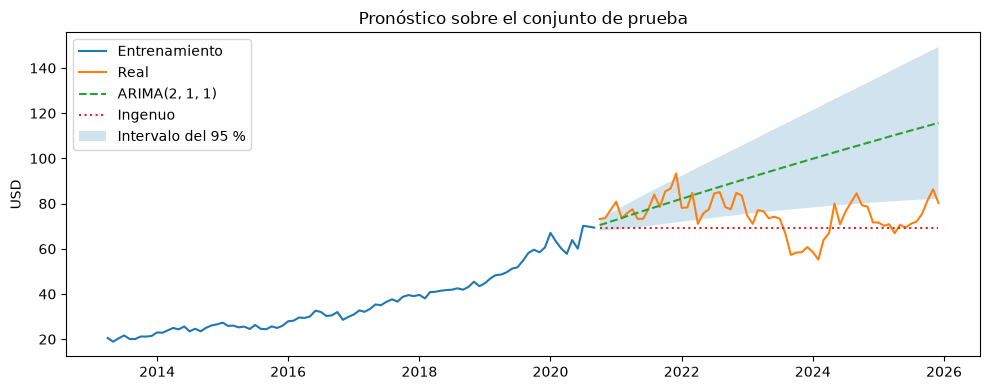

In [14]:
pronostico = modelo.get_forecast(steps=len(test))
intervalo = pronostico.conf_int(alpha=alpha)
prediccion = pronostico.predicted_mean

evaluacion = pd.DataFrame({'Real': test, 'Pronóstico': prediccion,
                           'Ingenuo': train.iloc[-1],
                           'Inferior 95%': intervalo.iloc[:, 0],
                           'Superior 95%': intervalo.iloc[:, 1]})
display(evaluacion.head())
display(evaluacion.tail())

plt.plot(train.tail(90), label='Entrenamiento')
plt.plot(test, label='Real')
plt.plot(prediccion, label=nombre, linestyle='--')
plt.plot(test.index, evaluacion['Ingenuo'], label='Ingenuo', linestyle=':')
plt.fill_between(test.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
                 alpha=0.2, label='Intervalo del 95 %')
plt.title('Pronóstico sobre el conjunto de prueba')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

### 7.2. Errores del pronóstico

MSE, RMSE, MAE y MAPE: cuanto menores, mejor. RMSE y MAE se expresan en USD, MSE en USD² y MAPE en porcentaje. Las métricas del bloque completo se complementan con sus primeros 30 días, un horizonte más corto.

In [15]:
def metricas(real, estimado):
    error = real - estimado
    mse = np.mean(error ** 2)
    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.mean(np.abs(error)),
            'MAPE (%)': np.mean(np.abs(error / real)) * 100}

metricas_test = pd.DataFrame({
    nombre: metricas(test, evaluacion['Pronóstico']),
    'Ingenuo': metricas(test, evaluacion['Ingenuo'])
}).T
print('Todo el conjunto de prueba:')
display(metricas_test.round(2))
print('Primeros 30 días de prueba:')
display(pd.DataFrame({
    nombre: metricas(test.iloc[:30], evaluacion['Pronóstico'].iloc[:30]),
    'Ingenuo': metricas(test.iloc[:30], evaluacion['Ingenuo'].iloc[:30])
}).T.round(2))

Todo el conjunto de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(2, 1, 1)",649.56,25.49,20.52,29.22
Ingenuo,91.51,9.57,8.05,10.57


Primeros 30 días de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(2, 1, 1)",67.04,8.19,6.33,8.13
Ingenuo,117.30,10.83,9.46,11.62


### 7.3. Reajuste y pronóstico de 30 días posteriores al dataset

Se conserva el orden elegido y se reestiman los parámetros con toda la serie. El horizonte empieza después de la última fecha descargada; este pronóstico no es una evaluación con datos observados.

,Pronóstico,Inferior 95%,Superior 95%
2026-01-01,80.95,75.72,86.19
2026-02-01,81.33,74.60,88.05
2026-03-01,81.24,73.44,89.03
2026-04-01,81.22,72.43,90.00
2026-05-01,81.23,71.55,90.90
2026-06-01,81.23,70.73,91.72
2026-07-01,81.23,69.98,92.47
2026-08-01,81.23,69.27,93.18
2026-09-01,81.23,68.60,93.85
2026-10-01,81.23,67.97,94.48


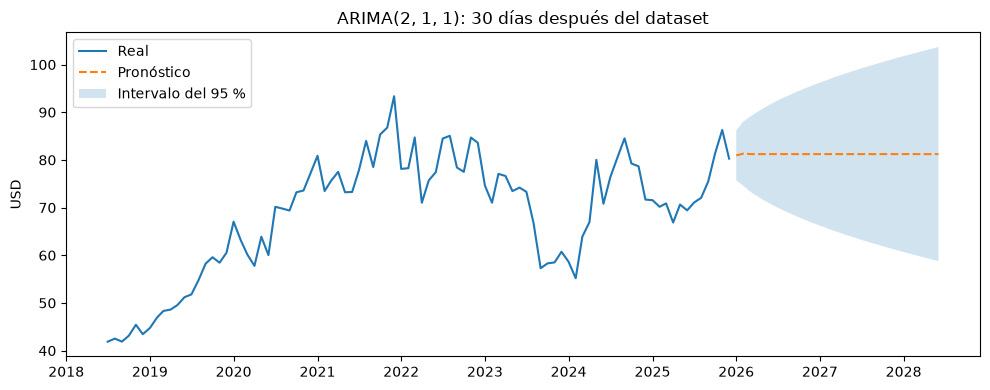

In [16]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    modelo_final = ARIMA(serie, order=orden_elegido, trend=trend, freq='MS').fit(method_kwargs={'maxiter': 200})
if not modelo_final.mle_retvals.get('converged', False):
    raise ValueError('El reajuste final no convergió. Revisar antes de pronosticar.')

futuro = modelo_final.get_forecast(steps=30)
intervalo_futuro = futuro.conf_int(alpha=alpha)
tabla_futuro = pd.DataFrame({'Pronóstico': futuro.predicted_mean,
                             'Inferior 95%': intervalo_futuro.iloc[:, 0],
                             'Superior 95%': intervalo_futuro.iloc[:, 1]})
display(tabla_futuro.round(2))

plt.plot(serie.tail(90), label='Real')
plt.plot(tabla_futuro['Pronóstico'], label='Pronóstico', linestyle='--')
plt.fill_between(tabla_futuro.index, tabla_futuro['Inferior 95%'],
                 tabla_futuro['Superior 95%'], alpha=0.2, label='Intervalo del 95 %')
plt.title(f'ARIMA{orden_elegido}: 30 días después del dataset')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusiones

In [17]:
print(f'1. Se analizaron {len(serie)} observaciones mensuales de NEE.')
print(f'2. Se seleccionó d={d}, según la prueba ADF.')
print(f'3. El modelo elegido por AIC fue ARIMA{orden_elegido}.')
print(f'4. RMSE del pronóstico: {metricas_test.loc[nombre, "RMSE"]:.2f}.')
print('5. Las pruebas de residuos se muestran en la tabla anterior.')
print('6. El pronóstico es una estimación; no reproduce exactamente cada variación futura.')

1. Se analizaron 312 observaciones mensuales de NEE.
2. Se seleccionó d=1, según la prueba ADF.
3. El modelo elegido por AIC fue ARIMA(2, 1, 1).
4. RMSE del pronóstico: 25.49.
5. Las pruebas de residuos se muestran en la tabla anterior.
6. El pronóstico es una estimación; no reproduce exactamente cada variación futura.


### Referencias

Material de clase: `01. Introducción a la programación para Series de Tiempo.ipynb`, `02. Series estacionarias y no estacionarias.ipynb`, `04. Modelos ARMA.ipynb` y los tres PDF de `TeoriayScrips`.

Consulta técnica: [yfinance](https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html), [ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html), [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html) y [Ljung–Box](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html).